In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np

In [2]:
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,mean_absolute_error

In [3]:
df=pd.read_csv("C:/Users/mnara/Downloads/joshimath 2010-02-05 to 2012-10-31.csv",header=0)

In [4]:
pd.DataFrame(df).head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,joshimath,05-02-2010,16.3,1.6,7.8,16.3,-0.7,7.1,-9.8,29.9,...,18.2,8,NaN,2010-02-05T07:00:39,2010-02-05T17:51:11,0.70,Clear,Clear conditions throughout the day.,clear-day,remote
1,joshimath,06-02-2010,17.9,3.7,8.7,17.9,1.9,7.8,-4.7,41.5,...,14.7,7,NaN,2010-02-06T06:59:56,2010-02-06T17:52:03,0.75,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,remote
2,joshimath,07-02-2010,16.5,4.6,9.0,16.5,3.0,8.3,0.5,56.8,...,11.1,6,NaN,2010-02-07T06:59:13,2010-02-07T17:52:54,0.77,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,remote
3,joshimath,08-02-2010,9.3,3.3,6.5,7.6,0.1,4.6,3.8,83.3,...,4.3,2,NaN,2010-02-08T06:58:28,2010-02-08T17:53:45,0.80,"Rain, Overcast",Cloudy skies throughout the day with rain.,rain,remote
4,joshimath,09-02-2010,9.9,0.3,4.5,7.2,-3.3,1.9,2.6,88.5,...,12.6,5,NaN,2010-02-09T06:57:42,2010-02-09T17:54:36,0.84,"Snow, Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,remote


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4957 entries, 0 to 4956
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              4957 non-null   object 
 1   datetime          4957 non-null   object 
 2   tempmax           4957 non-null   float64
 3   tempmin           4957 non-null   float64
 4   temp              4957 non-null   float64
 5   feelslikemax      4957 non-null   float64
 6   feelslikemin      4957 non-null   float64
 7   feelslike         4957 non-null   float64
 8   dew               4957 non-null   float64
 9   humidity          4957 non-null   float64
 10  precip            4957 non-null   float64
 11  precipprob        4957 non-null   int64  
 12  precipcover       4957 non-null   float64
 13  preciptype        2275 non-null   object 
 14  snow              600 non-null    float64
 15  snowdepth         600 non-null    float64
 16  windgust          600 non-null    float64


In [6]:
del df['name']
del df['snow']
del df['snowdepth']
del df['windgust']
del df['preciptype']
del df['sealevelpressure']
del df['severerisk']
del df['stations']


In [7]:
del df['description']


In [8]:
del df['visibility']


In [9]:
del df['conditions']


In [10]:
del df['precipprob']
del df['sunrise']
del df['sunset']



In [11]:

df['datetime'] = pd.to_datetime(df['datetime']).apply(lambda x: x.timestamp()).astype(float)


C:\Users\mnara\AppData\Local\Temp\ipykernel_18580\188550589.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['datetime'] = pd.to_datetime(df['datetime']).apply(lambda x: x.timestamp()).astype(float)


<Axes: xlabel='icon', ylabel='count'>

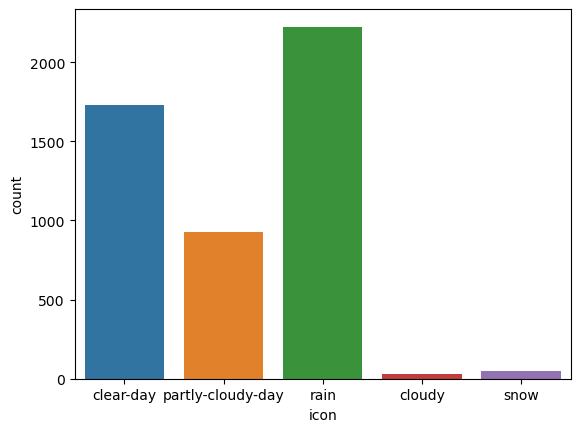

In [12]:
sns.countplot(x='icon',data=df)

In [13]:
df=pd.get_dummies(df,drop_first=True)

In [14]:
pd.DataFrame(df).head()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,moonphase,icon_cloudy,icon_partly-cloudy-day,icon_rain,icon_snow
0,1.272758e+09,16.3,1.6,7.8,16.3,-0.7,7.1,-9.8,29.9,0.0,...,284.5,6.2,213.0,18.2,8,0.70,0,0,0,0
1,1.275437e+09,17.9,3.7,8.7,17.9,1.9,7.8,-4.7,41.5,0.0,...,299.7,48.4,172.4,14.7,7,0.75,0,1,0,0
2,1.278029e+09,16.5,4.6,9.0,16.5,3.0,8.3,0.5,56.8,0.0,...,341.4,67.6,127.5,11.1,6,0.77,0,1,0,0
3,1.280707e+09,9.3,3.3,6.5,7.6,0.1,4.6,3.8,83.3,11.3,...,89.9,98.5,48.6,4.3,2,0.80,0,0,1,0
4,1.283386e+09,9.9,0.3,4.5,7.2,-3.3,1.9,2.6,88.5,19.1,...,123.7,64.5,145.0,12.6,5,0.84,0,0,1,0


<Axes: xlabel='icon_rain', ylabel='count'>

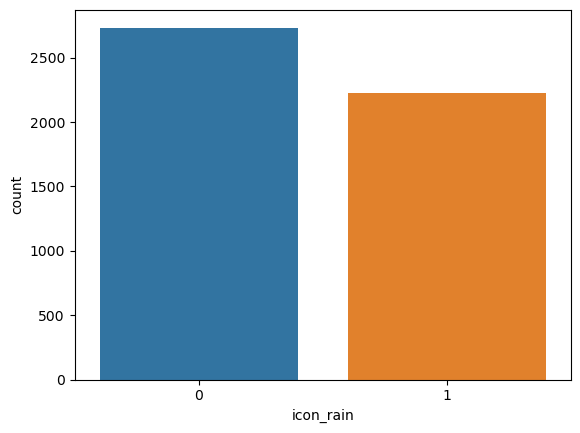

In [15]:
sns.countplot(x='icon_rain',data=df)

<Axes: xlabel='icon_cloudy', ylabel='count'>

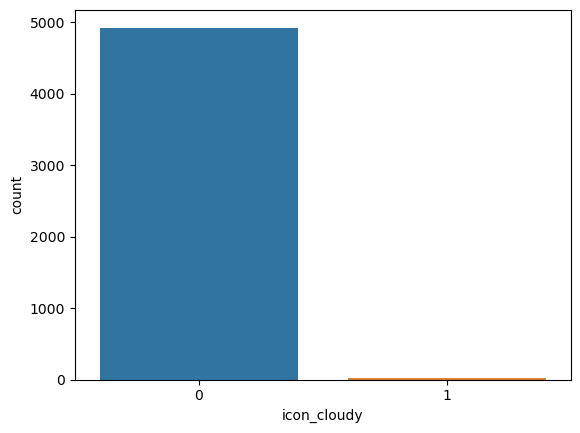

In [16]:
sns.countplot(x='icon_cloudy',data=df)

<Axes: xlabel='icon_partly-cloudy-day', ylabel='count'>

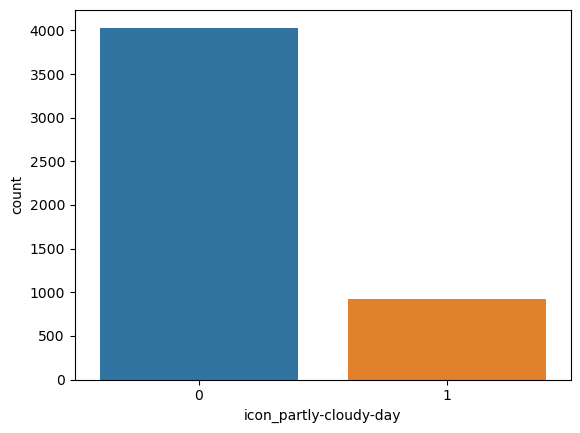

In [17]:
sns.countplot(x='icon_partly-cloudy-day',data=df)

<Axes: xlabel='icon_snow', ylabel='count'>

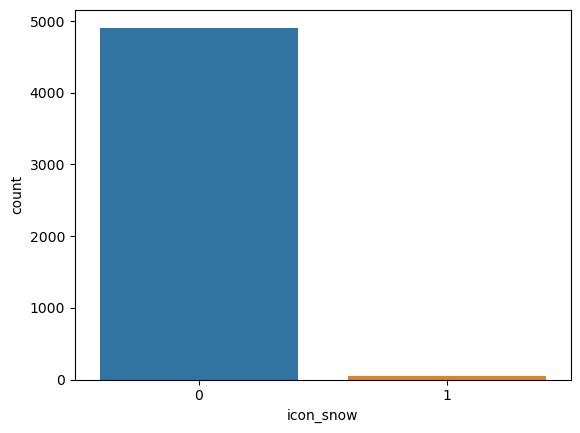

In [18]:

sns.countplot(x='icon_snow',data=df)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4957 entries, 0 to 4956
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   datetime                4957 non-null   float64
 1   tempmax                 4957 non-null   float64
 2   tempmin                 4957 non-null   float64
 3   temp                    4957 non-null   float64
 4   feelslikemax            4957 non-null   float64
 5   feelslikemin            4957 non-null   float64
 6   feelslike               4957 non-null   float64
 7   dew                     4957 non-null   float64
 8   humidity                4957 non-null   float64
 9   precip                  4957 non-null   float64
 10  precipcover             4957 non-null   float64
 11  windspeed               4957 non-null   float64
 12  winddir                 4957 non-null   float64
 13  cloudcover              4957 non-null   float64
 14  solarradiation          4957 non-null   

In [20]:
df.describe()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,moonphase,icon_cloudy,icon_partly-cloudy-day,icon_rain,icon_snow
count,4.957000e+03,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,...,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000
mean,1.479487e+09,20.650212,10.092092,14.696429,20.408311,9.161045,14.264051,5.144503,58.777587,3.476821,...,216.832742,34.875852,226.767722,19.582671,7.740367,0.483990,0.005850,0.186605,0.448658,0.009683
std,1.238661e+08,5.741487,6.302141,6.076463,5.658625,7.454192,6.552557,9.314843,21.685238,8.786149,...,77.612594,30.551219,69.131199,5.982511,1.839003,0.288815,0.076271,0.389633,0.497407,0.097936
min,1.262477e+09,-1.200000,-9.200000,-3.900000,-1.700000,-16.200000,-8.100000,-30.000000,7.700000,0.000000,...,0.200000,0.000000,11.900000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.372378e+09,17.000000,4.800000,9.800000,17.000000,3.200000,9.300000,-1.900000,40.600000,0.000000,...,189.100000,6.000000,177.600000,15.400000,7.000000,0.250000,0.000000,0.000000,0.000000,0.000000
50%,1.479427e+09,21.300000,10.600000,15.500000,21.300000,10.600000,15.400000,4.500000,57.000000,0.000000,...,238.600000,27.900000,222.000000,19.200000,8.000000,0.500000,0.000000,0.000000,0.000000,0.000000
75%,1.586477e+09,24.400000,16.000000,19.900000,24.400000,16.000000,19.900000,13.900000,79.700000,3.100000,...,266.400000,59.700000,279.800000,24.200000,9.000000,0.750000,0.000000,0.000000,1.000000,0.000000
max,1.701994e+09,34.700000,22.100000,27.000000,32.200000,22.100000,26.000000,20.200000,97.500000,151.000000,...,359.800000,100.000000,376.200000,32.500000,10.000000,0.980000,1.000000,1.000000,1.000000,1.000000


In [21]:
df.describe()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,moonphase,icon_cloudy,icon_partly-cloudy-day,icon_rain,icon_snow
count,4.957000e+03,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,...,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000,4957.000000
mean,1.479487e+09,20.650212,10.092092,14.696429,20.408311,9.161045,14.264051,5.144503,58.777587,3.476821,...,216.832742,34.875852,226.767722,19.582671,7.740367,0.483990,0.005850,0.186605,0.448658,0.009683
std,1.238661e+08,5.741487,6.302141,6.076463,5.658625,7.454192,6.552557,9.314843,21.685238,8.786149,...,77.612594,30.551219,69.131199,5.982511,1.839003,0.288815,0.076271,0.389633,0.497407,0.097936
min,1.262477e+09,-1.200000,-9.200000,-3.900000,-1.700000,-16.200000,-8.100000,-30.000000,7.700000,0.000000,...,0.200000,0.000000,11.900000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.372378e+09,17.000000,4.800000,9.800000,17.000000,3.200000,9.300000,-1.900000,40.600000,0.000000,...,189.100000,6.000000,177.600000,15.400000,7.000000,0.250000,0.000000,0.000000,0.000000,0.000000
50%,1.479427e+09,21.300000,10.600000,15.500000,21.300000,10.600000,15.400000,4.500000,57.000000,0.000000,...,238.600000,27.900000,222.000000,19.200000,8.000000,0.500000,0.000000,0.000000,0.000000,0.000000
75%,1.586477e+09,24.400000,16.000000,19.900000,24.400000,16.000000,19.900000,13.900000,79.700000,3.100000,...,266.400000,59.700000,279.800000,24.200000,9.000000,0.750000,0.000000,0.000000,1.000000,0.000000
max,1.701994e+09,34.700000,22.100000,27.000000,32.200000,22.100000,26.000000,20.200000,97.500000,151.000000,...,359.800000,100.000000,376.200000,32.500000,10.000000,0.980000,1.000000,1.000000,1.000000,1.000000


In [22]:
import seaborn as sns

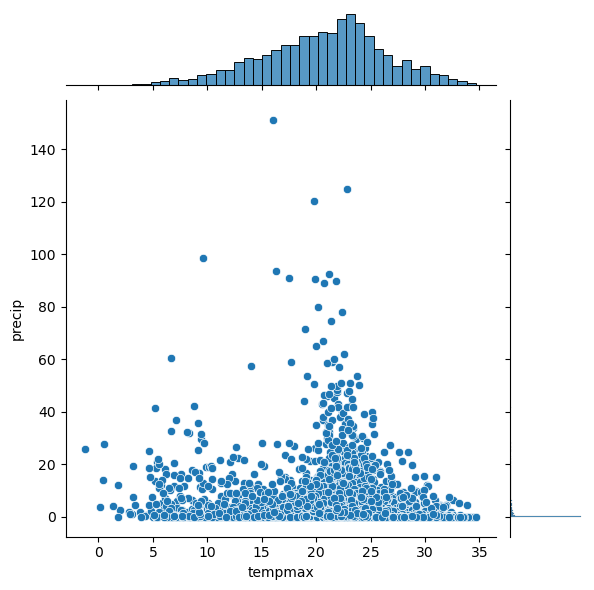

In [23]:
sns.jointplot(x='tempmax',y='precip',data=df)

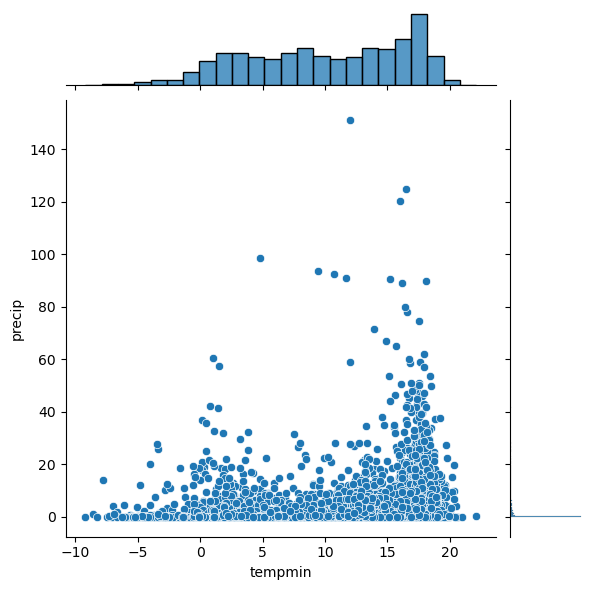

In [24]:
sns.jointplot(x='tempmin',y='precip',data=df)

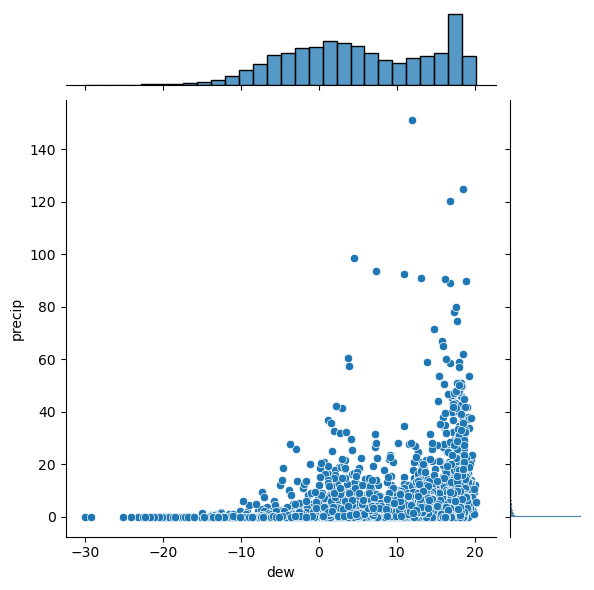

In [25]:
sns.jointplot(x='dew',y='precip',data=df)

In [26]:
lv = np.percentile(df.dew,[1])[0]

In [27]:
df.dew[(df.dew <0.3*lv)] = 0.3*lv

C:\Users\mnara\AppData\Local\Temp\ipykernel_18580\1883055690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dew[(df.dew <0.3*lv)] = 0.3*lv


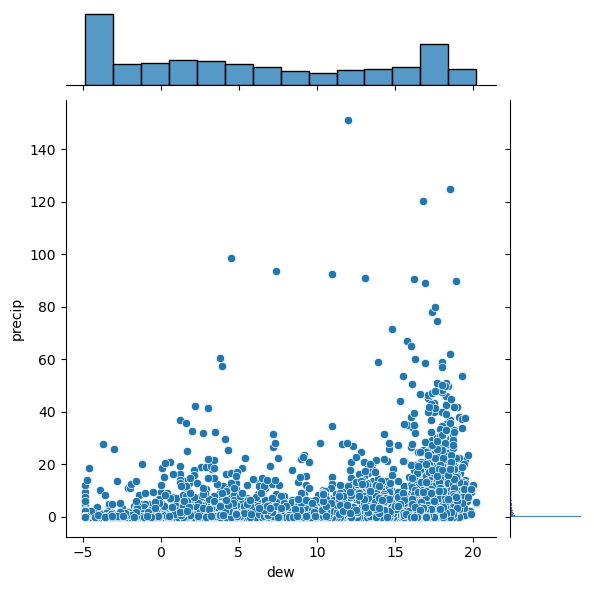

In [28]:
sns.jointplot(x='dew',y='precip',data=df)

In [29]:
df.corr()

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,winddir,cloudcover,solarradiation,solarenergy,uvindex,moonphase,icon_cloudy,icon_partly-cloudy-day,icon_rain,icon_snow
datetime,1.000000,-0.209809,-0.170418,-0.192408,-0.204454,-0.190358,-0.202078,-0.088972,-0.035622,-0.036029,...,-0.286378,0.073153,-0.013448,-0.013707,0.039162,-0.006275,0.027914,-0.061903,0.099427,0.151710
tempmax,-0.209809,1.000000,0.850503,0.950246,0.993874,0.851585,0.945229,0.499906,-0.020664,-0.004898,...,0.351227,-0.078589,0.670363,0.670712,0.522848,0.007843,-0.027534,-0.055791,0.111451,-0.252054
tempmin,-0.170418,0.850503,1.000000,0.967025,0.857916,0.995201,0.969358,0.839755,0.440397,0.252936,...,0.215231,0.277959,0.346482,0.347065,0.170101,0.006436,-0.018080,-0.143052,0.407164,-0.196615
temp,-0.192408,0.950246,0.967025,1.000000,0.949488,0.962812,0.997086,0.721098,0.252476,0.151518,...,0.269892,0.131755,0.525831,0.526291,0.346150,0.007167,-0.026164,-0.112521,0.300082,-0.218059
feelslikemax,-0.204454,0.993874,0.857916,0.949488,1.000000,0.860970,0.949891,0.525869,0.012645,0.001258,...,0.359686,-0.065824,0.651200,0.651519,0.510516,0.009073,-0.024657,-0.052466,0.119799,-0.273727
feelslikemin,-0.190358,0.851585,0.995201,0.962812,0.860970,1.000000,0.970840,0.828317,0.436937,0.240427,...,0.257937,0.258769,0.341202,0.341875,0.169972,0.007069,-0.019296,-0.130196,0.380706,-0.211117
feelslike,-0.202078,0.945229,0.969358,0.997086,0.949891,0.970840,1.000000,0.729033,0.272129,0.151967,...,0.297706,0.135264,0.507591,0.508103,0.333018,0.007676,-0.025580,-0.105329,0.295124,-0.230936
dew,-0.088972,0.499906,0.839755,0.721098,0.525869,0.828317,0.729033,1.000000,0.823142,0.386684,...,0.068997,0.448714,0.062542,0.062809,-0.075031,0.004933,-0.048032,-0.201749,0.573521,-0.108536
humidity,-0.035622,-0.020664,0.440397,0.252476,0.012645,0.436937,0.272129,0.823142,1.000000,0.452228,...,-0.059261,0.560500,-0.331135,-0.330881,-0.396998,-0.007276,-0.048060,-0.197145,0.584180,0.015446
precip,-0.036029,-0.004898,0.252936,0.151518,0.001258,0.240427,0.151967,0.386684,0.452228,1.000000,...,-0.162170,0.425458,-0.253707,-0.253824,-0.333463,-0.022904,-0.030359,-0.189556,0.421620,0.047675


In [30]:
del df ['solarradiation']

In [31]:
import statsmodels.api as sn


In [32]:
# Multiple variable creation using x_multi and y_multi and addition of constant by statsmodel.api library
x_multi=df.drop('precip',axis=1)
y_multi=df['precip']
x_multi_const=sn.add_constant(x_multi)

In [33]:
# Object creation
lm_multi=sn.OLS(y_multi,x_multi_const).fit()

In [34]:
lm_multi.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 precip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     208.1
Date:                Sun, 07 Jan 2024   Prob (F-statistic):               0.00
Time:                        10:11:32   Log-Likelihood:                -16290.
No. Observations:                4957   AIC:                         3.262e+04
Df Residuals:                    4936   BIC:                         3.276e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      9.6825      2.451      3.950      0.000       4.877      14.488
datetime               -2.587e-09   8.37e-10     -3.092      0.002   -4.23e-09   -9.47e-10
tempmax                   -1.3956      0.346     -4.033      0.000      -2.074      -0.717
tempmin                   -0.7501      0.355     -2.115      0.034      -1.445      -0.055
temp                       1.6747      0.656      2.552      0.011       0.388       2.961
feelslikemax               0.3657      0.279      1.311      0.190      -0.181       0.912
feelslikemin               0.2915      0.277      1.053      0.292      -0.251       0.834
feelslike                 -0.1397      0.555     -0.252      0.801      -1.227       0.948
dew                       -0.2012      0.070     -2.866      0.004      -0.339      -0.064
humidity                   0.0212      0.019      1.106      0.269      -0.016       0.059
precipcover                0.1913      0.006     34.642      0.000       0.180       0.202
windspeed                  0.1380      0.029      4.779      0.000       0.081       0.195
winddir                   -0.0058      0.002     -3.691      0.000      -0.009      -0.003
cloudcover                -0.0047      0.006     -0.749      0.454      -0.017       0.008
solarenergy               -0.0602      0.068     -0.883      0.377      -0.194       0.073
uvindex                   -0.1904      0.184     -1.032      0.302      -0.552       0.171
moonphase                 -0.1198      0.320     -0.375      0.708      -0.747       0.507
icon_cloudy               -0.9869      1.305     -0.756      0.450      -3.546       1.572
icon_partly-cloudy-day    -0.3185      0.339     -0.939      0.348      -0.983       0.346
icon_rain                 -3.9181      0.361    -10.862      0.000      -4.625      -3.211
icon_snow                 -3.2654      1.087     -3.004      0.003      -5.397      -1.134
==============================================================================
Omnibus:                     6605.992   Durbin-Watson:                   1.456
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2027989.080
Skew:                           7.387   Prob(JB):                         0.00
Kurtosis:                     100.982   Cond. No.                     3.97e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.97e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# MLR

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [36]:
# Splitting of data into test data (20%) and train data (80%) 
x_train,x_test,y_train,y_test=train_test_split(x_multi,y_multi,test_size=0.2,random_state=0)

In [37]:
lm_a=LinearRegression()

In [38]:
# Training of object
lm_a.fit(x_train,y_train)

LinearRegression()

In [39]:
y_test_a=lm_a.predict(x_test)

In [40]:
# Fraction of variance explained by model
r2_score(y_test,y_test_a)

0.44107094975661176

In [41]:
rmse = np.sqrt(mean_squared_error(y_test,y_test_a))
mae = mean_absolute_error(y_test,y_test_a)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.282794139540305
MAE: 2.896423455585139


# Ridge

In [42]:
from sklearn import preprocessing

In [43]:
# standardscaler is function of preprocessing
scaler=preprocessing.StandardScaler().fit(x_train)

In [44]:
x_train_s=scaler.transform(x_train)

In [45]:
x_test_s=scaler.transform(x_test)

In [46]:
from sklearn.linear_model import Ridge

In [47]:
lm_r=Ridge(alpha=0.5)

In [48]:
lm_r.fit(x_train_s,y_train)

Ridge(alpha=0.5)

In [49]:
# Fraction of variance explained by model
r2_score(y_test,lm_r.predict(x_test_s))

0.4411027170823786

In [50]:
rmse = np.sqrt(mean_squared_error(y_test,lm_r.predict(x_test_s)))
mae = mean_absolute_error(y_test,lm_r.predict(x_test_s))
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.282587173932379
MAE: 2.8904761703278754


# Lasso

In [51]:
from sklearn.linear_model import Lasso

In [52]:
lm_l=Lasso(alpha=0.2)

In [53]:
lm_l.fit(x_train_s,y_train)

Lasso(alpha=0.2)

In [54]:
# Fraction of variance explained by model
r2_score(y_test,lm_l.predict(x_test_s))

0.42962662399969265

In [55]:
rmse = np.sqrt(mean_squared_error(y_test,lm_r.predict(x_test_s)))
mae = mean_absolute_error(y_test,lm_r.predict(x_test_s))
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.282587173932379
MAE: 2.8904761703278754


# Decision Tree

In [56]:
from sklearn import tree

In [57]:
regtree=tree.DecisionTreeRegressor(max_depth=3)

In [58]:
regtree.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=3)

In [59]:
y_test_rt=regtree.predict(x_test)

In [60]:
# Fraction of variance explained by model
r2_score(y_test,y_test_rt)

0.5331681032781133

In [61]:
rmse = np.sqrt(mean_squared_error(y_test, y_test_rt))
mae = mean_absolute_error(y_test,y_test_rt)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 6.655795254853217
MAE: 2.3658797065354813


# Random Forest

In [62]:
from sklearn.ensemble import RandomForestRegressor

In [63]:
rf_reg=RandomForestRegressor(n_estimators=1500,bootstrap=True,n_jobs=-1,random_state=0)

In [64]:
rf_reg.fit(x_train,y_train)

RandomForestRegressor(n_estimators=1500, n_jobs=-1, random_state=0)

In [65]:
# Fraction of variance explained by model
r2_score(y_test,rf_reg.predict(x_test))

0.531592102891282

In [66]:
rmse = np.sqrt(mean_squared_error(y_test,rf_reg.predict(x_test)))
mae = mean_absolute_error(y_test,rf_reg.predict(x_test))

In [67]:
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 6.667020599403592
MAE: 2.3473381048387107


In [68]:
rf_clf = RandomForestRegressor(n_estimators=250,random_state=42)

In [69]:
params_grid = {"max_features" : [4,5,6,7,8,9,10],
              "min_samples_split": [2, 3, 10],
              }

In [70]:
from sklearn.model_selection import GridSearchCV

In [71]:
grid_search = GridSearchCV(rf_clf, params_grid,
                           n_jobs=-1, cv=5, scoring='r2')

In [72]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestRegressor(n_estimators=250, random_state=42),
             n_jobs=-1,
             param_grid={'max_features': [4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [2, 3, 10]},
             scoring='r2')

In [73]:
grid_search.best_params_ 

{'max_features': 8, 'min_samples_split': 3}

In [74]:
cvrf_ref = grid_search.best_estimator_

In [75]:
r2_score(y_test,cvrf_ref.predict(x_test))

0.5417187821339837

In [76]:
rmse = np.sqrt(mean_squared_error(y_test,cvrf_ref.predict(x_test)))
mae = mean_absolute_error(y_test,cvrf_ref.predict(x_test))

In [77]:
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 6.5945584518127065
MAE: 2.273035067844342


In [117]:
help(grid_search
    )


Help on GridSearchCV in module sklearn.model_selection._search object:

class GridSearchCV(BaseSearchCV)
 |  GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
 |  
 |  Exhaustive search over specified parameter values for an estimator.
 |  
 |  Important members are fit, predict.
 |  
 |  GridSearchCV implements a "fit" and a "score" method.
 |  It also implements "score_samples", "predict", "predict_proba",
 |  "decision_function", "transform" and "inverse_transform" if they are
 |  implemented in the estimator used.
 |  
 |  The parameters of the estimator used to apply these methods are optimized
 |  by cross-validated grid-search over a parameter grid.
 |  
 |  Read more in the :ref:`User Guide <grid_search>`.
 |  
 |  Parameters
 |  ----------
 |  estimator : estimator object
 |      This is assumed to implement the scikit-learn estimator interface.
 |      Either es

# XGBoost

In [78]:
import xgboost as xgb

In [79]:
xgb_reg=xgb.XGBRegressor(max_depth=3,n_estimator=1100,learning_rate=0.03,n_jobs=-1)

In [80]:
xgb_reg.fit(x_train,y_train)

[10:13:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "n_estimator" } are not used.



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimator=1100, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, predictor=None, ...)

In [81]:
# Fraction of variance explained by model
r2_score(y_test,xgb_reg.predict(x_test))

0.5203052240166367

In [82]:
rmse = np.sqrt(mean_squared_error(y_test,xgb_reg.predict(x_test)))
mae = mean_absolute_error(y_test,xgb_reg.predict(x_test))

In [83]:
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 6.746867592850798
MAE: 2.2853605416933855


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

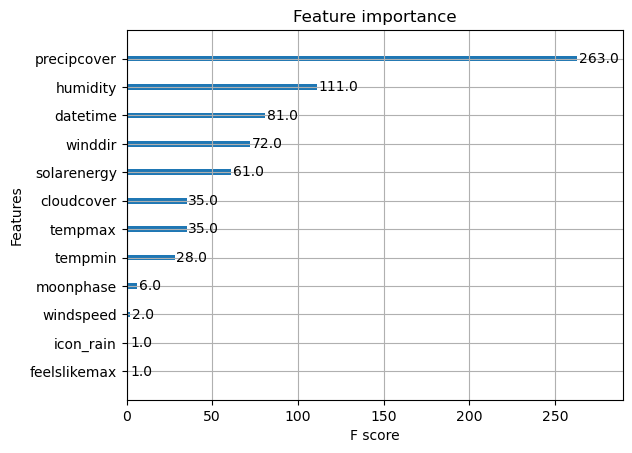

In [84]:
xgb.plot_importance(xgb_reg)

# Knn

In [85]:
# Creation of clf_knn_1 model object and fitting it with data
from sklearn.neighbors import KNeighborsRegressor
clf_knn_1 = KNeighborsRegressor(n_neighbors=60
                               )
clf_knn_1.fit(x_train_s, y_train)

KNeighborsRegressor(n_neighbors=60)

In [86]:
r2_score(y_test, clf_knn_1.predict(x_test_s))

0.41989834423215633

In [87]:
rmse = np.sqrt(mean_squared_error(y_test,clf_knn_1.predict(x_test_s)))
mae = mean_absolute_error(y_test,clf_knn_1.predict(x_test_s))
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.419450561287164
MAE: 2.5107442876344086


In [88]:
mean_squared_error(y_test, clf_knn_1.predict(x_test_s))

55.04824663138441

In [89]:
rmse = np.sqrt(mean_squared_error(y_test, clf_knn_1.predict(x_test_s)))
mae = mean_absolute_error(y_test, clf_knn_1.predict(x_test_s))

In [90]:
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.419450561287164
MAE: 2.5107442876344086


In [91]:
from sklearn.model_selection import GridSearchCV

In [92]:
params = {'n_neighbors': range(2,60,1)}

In [93]:
grid_search_cv = GridSearchCV(KNeighborsRegressor(), params)

In [94]:
grid_search_cv.fit(x_train_s, y_train)

GridSearchCV(estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': range(2, 60)})

In [95]:
grid_search_cv.best_params_

{'n_neighbors': 11}

In [96]:
optimised_KNN = grid_search_cv.best_estimator_

In [97]:
y_test_pred = optimised_KNN.predict(x_test_s) 

In [98]:
r2_score(y_test, y_test_pred)

0.42321004627367764

In [99]:
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test,y_test_pred)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.398242056091964
MAE: 2.492952712609971


# bagging

In [100]:
from sklearn.ensemble import BaggingRegressor

In [101]:
bag_reg=BaggingRegressor(base_estimator=regtree,n_estimators=1800,bootstrap=True,n_jobs=-1,random_state=0)

In [102]:
bag_reg.fit(x_train,y_train)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingRegressor(base_estimator=DecisionTreeRegressor(max_depth=3),
                 n_estimators=1800, n_jobs=-1, random_state=0)

In [103]:
r2_score(y_test,bag_reg.predict(x_test))

0.5295580012368997

In [104]:
rmse = np.sqrt(mean_squared_error(y_test, bag_reg.predict(x_test)))
mae = mean_absolute_error(y_test,bag_reg.predict(x_test))
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 6.681480973269428
MAE: 2.3114704763636227


In [105]:
dot_data=tree.export_graphviz(regtree,out_file=None,filled=True,feature_names=x_train.columns)

In [106]:
from IPython.display import Image

In [107]:
import pydotplus

In [108]:
fraph=pydotplus.graph_from_dot_data(dot_data)

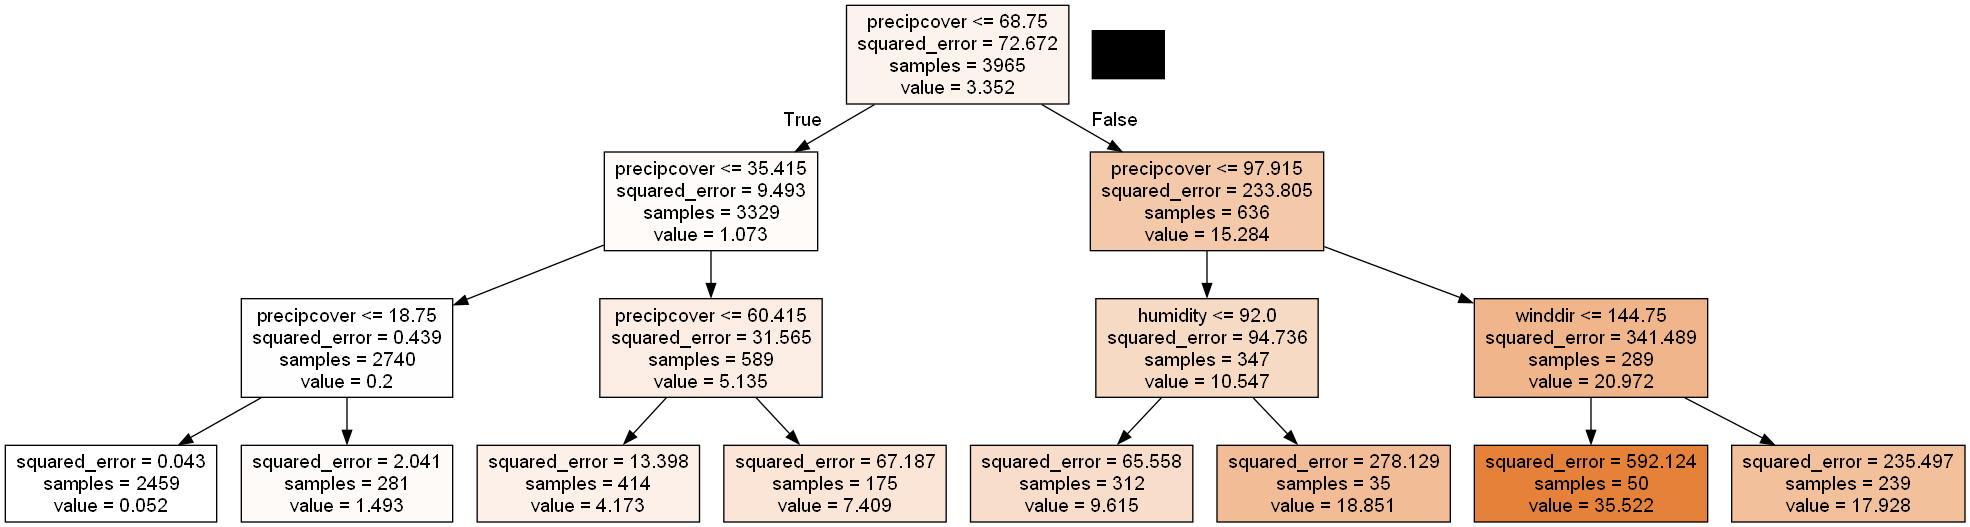

In [109]:
Image(fraph.create_png())

# Ada Boost

In [110]:
from sklearn.ensemble import AdaBoostRegressor

In [111]:
ada_clf = AdaBoostRegressor(learning_rate =0.002, n_estimators =89)

In [112]:
ada_clf.fit(x_train, y_train)

AdaBoostRegressor(learning_rate=0.002, n_estimators=89)

In [113]:
r2_score(y_test,ada_clf.predict(x_test))

0.535127887041949

In [114]:
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test,y_test_pred)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 7.398242056091964
MAE: 2.492952712609971


# Deployment

In [115]:
# Please input college in tier,city(metro or non metro),previous ctc,previous job change,experience,graduation marks and role(1 for manager))
import datetime

def date_to_float(date_string):
    try:
        date_obj = datetime.datetime.strptime(date_string, '%Y-%m-%d')
        timestamp = date_obj.timestamp()
        return timestamp
    except ValueError:
        print("Invalid date format. Please use the format 'YYYY-MM-DD'.")
        return None

# Example usage:
input_date = input("Enter a date in the format 'YYYY-MM-DD': ")
datetime = date_to_float(input_date)


print('tempmax:')
tempmax=float(input())
print('tempmin:')
tempmin=input()
print('temp:')
temp=input()
print('feelslikemax:')
feelslikemax=float(input())
print('feelslikemin:')
feelslikemin=float(input())
print('feelslike:')
feelslike=float(input())
print('dew:')
dew=int(input())
print('humidity:')
humidity=input()
print('precipcover:')
precipcover=input()
print('windspeed:')
windspeed=input()
print('winddir:')
winddir=input()
print('cloudcover:')
cloudcover=input()
print('solarenergy:')
solarenergy=input()
print('uvindex:')
uvindex=float(input())


print('moonphase:')
moonphase=float(input())
print('icon_cloudy(1):')
icon_cloudy=int(input())
print('icon_partly_cloudy_day(1):')
icon_partly_cloudy_day=int(input())
print('icon_rain(1):')
icon_rain=int(input())
print('icon_snow(1):')
icon_snow=int(input())

input_da = np.array([[datetime, tempmax, tempmin, temp, feelslikemax, feelslikemin, feelslike, dew, humidity, precipcover, windspeed, winddir, cloudcover, solarenergy, uvindex,moonphase,icon_cloudy,icon_partly_cloudy_day,icon_rain,icon_snow]])

h = cvrf_ref.predict(input_da)
if h[0]>=0.1:
    print('Predicted precipitation is {} mm'.format(h[0]))
else:
    print('Predicted precipitation is 0 mm')



KeyboardInterrupt: Interrupted by user